# Анализ лояльности пользователей Яндекс Афиши

# Этапы выполнения проекта

### Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
#librarys
#!pip install sqlalchemy
#!pip install psycopg2
#from pandas_datareader import data as pdr
!pip install phik
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

#string for connection
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)
engine = create_engine(connection_string)
#sql query
query = '''
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
),
purchase_data AS (
    SELECT 
        p.user_id,
        p.device_type_canonical,
        p.order_id,
        p.created_dt_msk AS order_dt,
        p.created_ts_msk AS order_ts,
        p.currency_code,
        p.revenue,
        p.tickets_count,
        -- Рассчитываем количество дней между текущей и предыдущей покупкой
        CAST(EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk))) AS INTEGER) AS days_since_prev,
        p.event_id,
        e.event_name_code AS event_name,
        e.event_type_main,
        p.service_name,
        r.region_name,
        c.city_name
    FROM afisha.purchases p
    INNER JOIN afisha.events e ON p.event_id = e.event_id
    LEFT JOIN afisha.city c ON e.city_id = c.city_id
    LEFT JOIN afisha.regions r ON c.region_id = r.region_id
    WHERE p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм')
SELECT *
FROM purchase_data
ORDER BY user_id
'''
#dataframe
df = pd.read_sql_query(query, con=engine)

In [2]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Все выгрузилось корректно. Названия столбцов соответствуют `snake_case`

Наша таблица содержит 15 столбцов и 290611 строк - этого более, чем достаточно для анализа.

В таблице использованы следующие типы данных:
 - 2 - `datetime64`
 - 8 - `object`
 - 3 - `int64`
 - 2 - `float64` 

Столбцы `int64` и `float64` традиционно можно оптимизировать.

---

###  Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Конвертируем тенге в рубли и добавим новый столбец.

Загружаем таблицу с курсом

In [4]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
df_tenge.info()
df_tenge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Приведем столбец `data` к datetime

In [5]:
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

Объединим таблицы по дате

In [6]:
df_merged = pd.merge(
    df, 
    df_tenge[['data', 'curs']], 
    left_on='order_dt', 
    right_on='data', 
    how='left'
)
df_merged.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,curs
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,18.6972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,18.3419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,19.6475
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,18.5010
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,19.6648


In [7]:
df_merged['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

Добавим новый столбец только с рублями

In [8]:
df_merged['revenue_rub'] = np.where(
    df_merged['currency_code'] == 'kzt',
    df_merged['revenue'] * (df_merged['curs'] / 100),  # для тенге пересчитываем
    df_merged['revenue']                               # для рублей оставляем как есть
)

In [9]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Уберем лишние столбцы

In [10]:
df_merged = df_merged.drop(columns=['data', 'curs'])

In [11]:
df = df_merged.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [12]:
def show_missing_stats(tmp0):
    #Функция для отображения статистики пропущенных значений в DataFrame.
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean(),
        'Процент пропусков': tmp0.isnull().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}', 'Процент пропусков': '{:.1f}%'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков,Процент пропусков
days_since_prev,21933,0.0755,7.5%


Пропуски присутствуют только в столбце `days_since_prev` - 21933 пропуска. Это означает, что 7.5% пользователей совершили не более одного заказа. Пропуски указаны как `NaN`. Столбец мы рассчитывали сами - так и должно быть.

Понизим разрядность данных `int64` и `float64`

In [13]:
for column in ['revenue_rub', 'revenue', 'days_since_prev']:
    df[column] = pd.to_numeric(df[column], errors='coerce', downcast='float')
for column in ['tickets_count', 'order_id', 'event_id']:
    df[column] = pd.to_numeric(df[column], errors='coerce', downcast='integer')

Проверим результат

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Отлично, вместо 38 MB наша таблица теперь занимает 30 MB.

Теперь проверим уникальные значения по столбцам

In [15]:
# Краткая статистика по всем столбцам
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = len(df[col])
    print(f"{col:22} | уникальных: {unique_count:7} | всего: {total_count:5} | доля: {unique_count/total_count:.2%}")

user_id                | уникальных:   21933 | всего: 290611 | доля: 7.55%
device_type_canonical  | уникальных:       2 | всего: 290611 | доля: 0.00%
order_id               | уникальных:  290611 | всего: 290611 | доля: 100.00%
order_dt               | уникальных:     153 | всего: 290611 | доля: 0.05%
order_ts               | уникальных:  280753 | всего: 290611 | доля: 96.61%
currency_code          | уникальных:       2 | всего: 290611 | доля: 0.00%
revenue                | уникальных:   42522 | всего: 290611 | доля: 14.63%
tickets_count          | уникальных:      22 | всего: 290611 | доля: 0.01%
days_since_prev        | уникальных:     149 | всего: 290611 | доля: 0.05%
event_id               | уникальных:   22427 | всего: 290611 | доля: 7.72%
event_name             | уникальных:   15248 | всего: 290611 | доля: 5.25%
event_type_main        | уникальных:       7 | всего: 290611 | доля: 0.00%
service_name           | уникальных:      36 | всего: 290611 | доля: 0.01%
region_name          

In [16]:
# Быстрый обзор всех столбцов
# первые n уникальных значений
n = 5
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].sort_values().unique()[:n])
    if len(df[col].unique()) > n:
        print(f"... и еще {len(df[col].unique()) - n} уникальных значений")


user_id:
['0002849b70a3ce2' '0005ca5e93f2cf4' '000898990054619' '00096d1f542ab2b'
 '000a55a418c128c']
... и еще 21928 уникальных значений

device_type_canonical:
['desktop' 'mobile']

order_id:
[  1  30  59  88 117]
... и еще 290606 уникальных значений

order_dt:
<DatetimeArray>
['2024-06-01 00:00:00', '2024-06-02 00:00:00', '2024-06-03 00:00:00',
 '2024-06-04 00:00:00', '2024-06-05 00:00:00']
Length: 5, dtype: datetime64[ns]
... и еще 148 уникальных значений

order_ts:
<DatetimeArray>
['2024-06-01 00:00:42', '2024-06-01 00:01:30', '2024-06-01 00:01:58',
 '2024-06-01 00:03:13', '2024-06-01 00:03:34']
Length: 5, dtype: datetime64[ns]
... и еще 280748 уникальных значений

currency_code:
['kzt' 'rub']

revenue:
[-90.76 -17.94 -10.77  -8.53  -7.18]
... и еще 42517 уникальных значений

tickets_count:
[1 2 3 4 5]
... и еще 17 уникальных значений

days_since_prev:
[0. 1. 2. 3. 4.]
... и еще 145 уникальных значений

event_id:
[4436 5785 8817 8849 8850]
... и еще 22422 уникальных значений

eve

Проверим явные дубликаты

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['revenue'].describe()

count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue, dtype: float64

По категориальным столбцам, вроде бы, все нормально. Явные дубликаты отсутствуют. Смущает наличие отрицательной и нулевой выручки от заказов. Маловероятно, что это благотворительность.

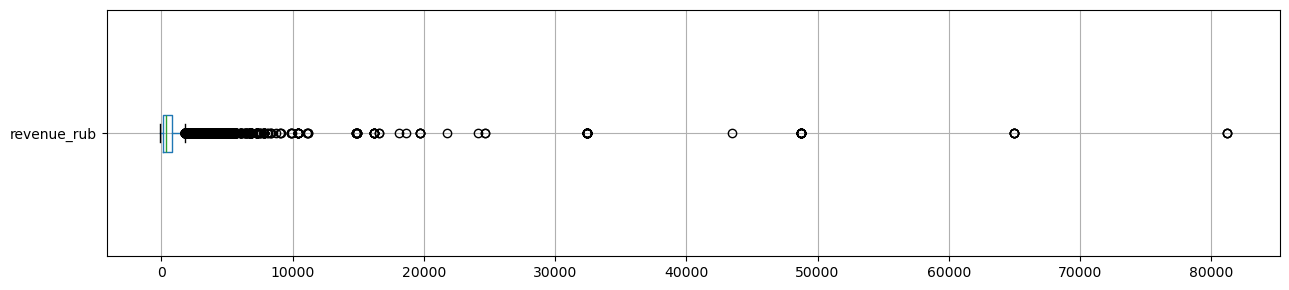

Выбросы, выходящие за пределы 1.5*IQR: 10449, в долях от общего количества - 0.04


In [19]:
c = 'revenue_rub'

plt.figure(figsize=(13, 3))

df.boxplot(column=c, vert=False)
plt.tight_layout()
plt.show()

# Выбросы
Q1 = df[c].quantile(0.25)
Q3 = df[c].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[c] < Q1 - 1.5 * IQR) | (df[c] > Q3 + 1.5 * IQR)]
print(f"Выбросы, выходящие за пределы 1.5*IQR: {len(outliers)}, в долях от общего количества - {len(outliers)/len(df):.2f}")

Разброс данных очень велик. Подавляющее количество значений находится в диапазоне от 100 до 800 рублей. Медианное в два раза меньше среднего - распределение имеет правый хвост.

На ящике все наглядно. Количество выбросов 10,5 тысяч.

In [20]:
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

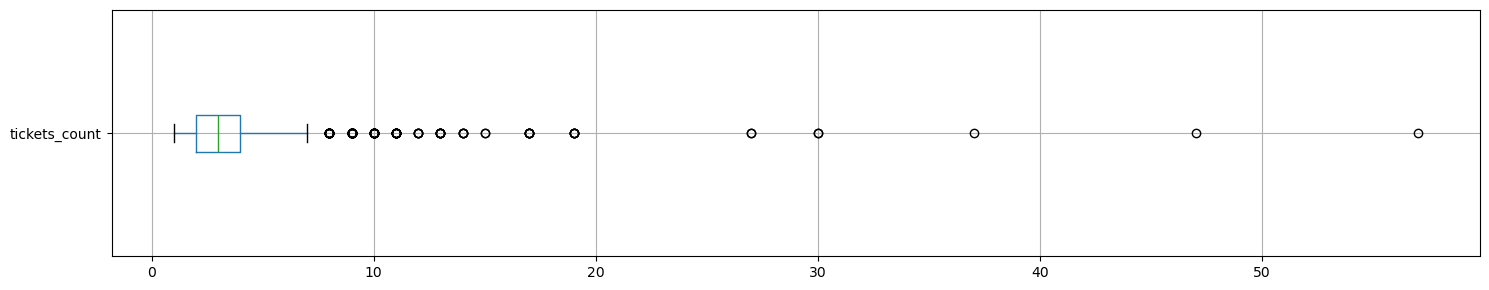

Выбросы, выходящие за пределы 1.5*IQR: 126, в долях от общего количества - 0.0004


In [21]:
c = 'tickets_count'

plt.figure(figsize=(15, 3))

df.boxplot(column=c, vert=False)
plt.tight_layout()
plt.show()

# Выбросы
Q1 = df[c].quantile(0.25)
Q3 = df[c].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[c] < Q1 - 1.5 * IQR) | (df[c] > Q3 + 1.5 * IQR)]
print(f"Выбросы, выходящие за пределы 1.5*IQR: {len(outliers)}, в долях от общего количества - {len(outliers)/len(df):.4f}")

Среднее и медианное значения достаточно близки, данные распределены достаточно равномерно (правый хвост присутствует), не считая редких вылетов более 4-х билетов.

In [22]:
# Находим значение 99-го процентиля
full_df = len(df)
percentile_99 = df['revenue_rub'].quantile(0.99)

# Фильтруем: оставляем только те строки, где значение <= 99-го процентиля
df = df[df['revenue_rub'] <= percentile_99].copy()
df.info()
print(f'\nОтфильтровано {(1 - len(df)/full_df)*100:.2f}%')

<class 'pandas.core.frame.DataFrame'>
Index: 287786 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287786 non-null  object        
 1   device_type_canonical  287786 non-null  object        
 2   order_id               287786 non-null  int32         
 3   order_dt               287786 non-null  datetime64[ns]
 4   order_ts               287786 non-null  datetime64[ns]
 5   currency_code          287786 non-null  object        
 6   revenue                287786 non-null  float64       
 7   tickets_count          287786 non-null  int8          
 8   days_since_prev        266060 non-null  float32       
 9   event_id               287786 non-null  int32         
 10  event_name             287786 non-null  object        
 11  event_type_main        287786 non-null  object        
 12  service_name           287786 non-null  object   

`Что было сделано`

- Написали SQL-запрос, загрузили его в DataFrame
- Таблица получилась увесистая (15 столбцов и 290611 строк)
- Подгрузили таблицу с курсом тенге, добавили новый столбец с данными только в рублях
- Посмотрели пропуски, явных дубликатов не обнаружили
- Проверили уникальные значения в категориальных столбцах - ничего криминального не обнаружили
- Определили наличие в выручке отрицательных и нулевых значений
- Построили ящики по столбцам `revenue_rub` и `tickets_count`, нашли в первом случае сильные выбросы
- Отфильтровали `df` по 99 процентилю `revenue_rub` (~1%), осталось 287786 строк

---

### Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [23]:
df_sorted = df.sort_values('order_ts').copy()

# Создаем профиль пользователя, группируя по user_id
user_profile = df_sorted.groupby('user_id').agg(
    # Дата первого и последнего заказа
    first_order_date=('order_dt', 'first'),
    last_order_date=('order_dt', 'last'),
    
    # Устройство первого заказа
    first_device=('device_type_canonical', 'first'),
    
    # Регион первого заказа
    first_region=('region_name', 'first'),
    
    # Билетный партнер первого заказа
    first_partner=('service_name', 'first'),
    
    # Жанр первого мероприятия
    first_genre=('event_type_main', 'first'),
    
    # Общее количество заказов
    total_orders=('order_id', 'count'),
    
    # Средняя выручка с заказа
    avg_revenue=('revenue_rub', 'mean'),
    
    # Среднее количество билетов в заказе
    avg_tickets=('tickets_count', 'mean'),
    
    # Среднее время между заказами
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# Просмотр результатов
display(user_profile.head())

,user_id,first_order_date,last_order_date,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue,avg_tickets,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0


Сводная таблица по профилям пользователей составлена

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [24]:
# Общая статистика по пользователям
total_users_old = len(user_profile)
total_orders_sum = user_profile['total_orders'].sum()
total_revenue_sum = (user_profile['avg_revenue'] * user_profile['total_orders']).sum()

print(f"Общее число пользователей в выборке: {total_users_old}")
print(f"Средняя выручка с одного заказа: {total_revenue_sum / total_orders_sum:.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {user_profile['is_two'].mean() * 100:.2f}%")
print(f"Доля пользователей с 5+ заказами: {user_profile['is_five'].mean() * 100:.2f}%")

Общее число пользователей в выборке: 21854
Средняя выручка с одного заказа: 518.03 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


Перейдем к анализу статистических показателей

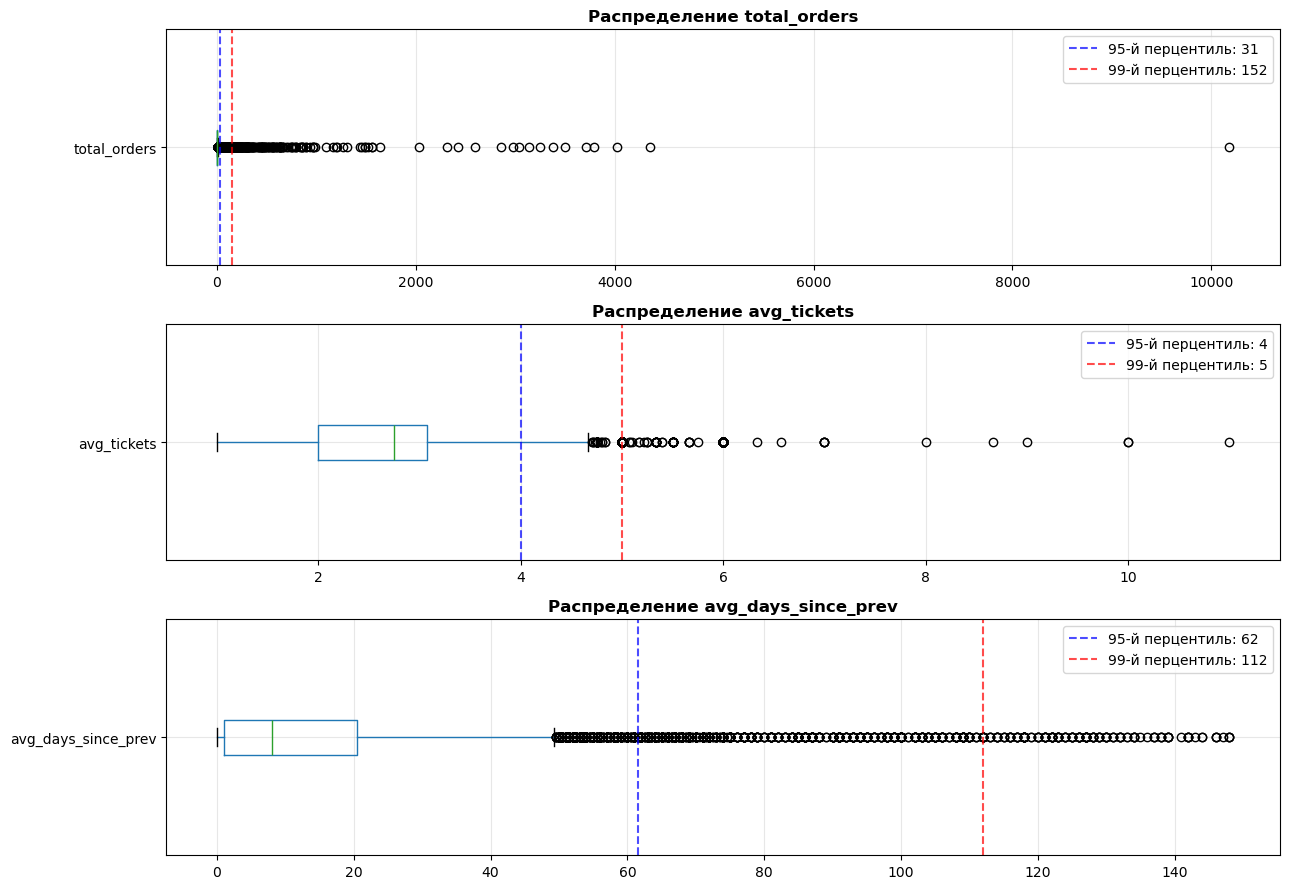

,Показатель,Медиана,Среднее,Минимум,Максимум,Стд. отклонение,95-й перцентиль,99-й перцентиль,Кол-во выбросов (>95%),Кол-во выбросов (>99%),% выбросов 95,% выбросов 99
0,total_orders,2.00,13.17,1.00,10181.00,121.67,31,152,1093,216,5.00%,0.99%
1,avg_tickets,2.75,2.74,1.00,11.00,0.91,4,5,968,194,4.43%,0.89%
2,avg_days_since_prev,8.00,15.84,0.00,148.00,22.30,62,112,674,135,3.08%,0.62%


In [25]:
columns_to_plot = ['total_orders', 'avg_tickets', 'avg_days_since_prev']

# Создаем список для сбора статистики
statistics_data = []

# Создаем subplots вертикально
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(13, 3*len(columns_to_plot)))

for i, col in enumerate(columns_to_plot):
    # Boxplot
    user_profile.boxplot(column=col, vert=False, ax=axes[i])
    axes[i].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    
    # Расчет статистики
    median_val = user_profile[col].median()
    mean_val = user_profile[col].mean()
    std_val = user_profile[col].std()
    
    # Анализ выбросов для 95 перцентиля
    percentile_95 = user_profile[col].quantile(0.95)
    outliers_95 = user_profile[user_profile[col] > percentile_95]
    outliers_count_95 = len(outliers_95)
    outliers_pct_95 = outliers_count_95 / len(user_profile) * 100
    
    # Анализ выбросов для 99 перцентиля
    percentile_99 = user_profile[col].quantile(0.99)
    outliers_99 = user_profile[user_profile[col] > percentile_99]
    outliers_count_99 = len(outliers_99)
    outliers_pct_99 = outliers_count_99 / len(user_profile) * 100
        
    # Добавляем вертикальную линию для 95 перцентиля
    axes[i].axvline(x=percentile_95, color='blue', linestyle='--', alpha=0.7, 
                   label=f'95-й перцентиль: {percentile_95:.0f}')
    
    # Добавляем вертикальную линию для 99 перцентиля
    axes[i].axvline(x=percentile_99, color='red', linestyle='--', alpha=0.7, 
                   label=f'99-й перцентиль: {percentile_99:.0f}')
    
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)
    
    # Собираем статистику в список
    statistics_data.append({
        'Показатель': col,
        'Медиана': f'{median_val:.2f}',
        'Среднее': f'{mean_val:.2f}',
        'Минимум': f'{user_profile[col].min():.2f}',
        'Максимум': f'{user_profile[col].max():.2f}',
        'Стд. отклонение': f'{std_val:.2f}',
        '95-й перцентиль': f'{percentile_95:.0f}',
        '99-й перцентиль': f'{percentile_99:.0f}',
        'Кол-во выбросов (>95%)': outliers_count_95,
        'Кол-во выбросов (>99%)': outliers_count_99,
        '% выбросов 95': f'{outliers_pct_95:.2f}%',
        '% выбросов 99': f'{outliers_pct_99:.2f}%'
    })

plt.tight_layout()
plt.show()

# Создаем DataFrame для красивого отображения
statistics_df = pd.DataFrame(statistics_data)
display(statistics_df)

Попробовали построить ящики, чтобы было красиво, для показателей. Добавили сводную табличку с основными метриками.

Распределение `total_orders` из-за большого количества аномалий и экстремальных значений (до 10181) не позволяет даже наглядно рассмотреть график.

Распределение `avg_tickets` выглядит намного лучше, 95-й перцентиль заходит в зону верхнего порога выбросов Q3 + 1.5 * IQR. Стандартное отклонение здесь невелико, лучше анализировать все данные.

Примем решение избавиться от выбросов 99 перцентиля по полю `total_orders`, так как это не настолько сильно скажется на итоговой статистике, но позволит избавиться от экстремальных выбросов.

In [26]:
# Фильтруем: оставляем только те строки, где значение <= 99-го процентиля
per_99 = user_profile['total_orders'].quantile(0.99)
user_profile = user_profile[user_profile['total_orders'] <= per_99].copy()
print(f'\nОсталось: {(len(user_profile) / total_users_old)*100:.1f}% пользователей ({len(user_profile)} строк)')


Осталось: 99.0% пользователей (21638 строк)


---

### Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [27]:
# Группировка по типу первого мероприятия (first_genre)
genre_segments = user_profile['first_genre'].value_counts().reset_index()
genre_segments.columns = ['Тип первого мероприятия', 'Количество пользователей']
genre_segments['Доля (%)'] = (genre_segments['Количество пользователей'] / len(user_profile) * 100).round(2)
genre_segments = genre_segments.sort_values('Количество пользователей', ascending=False)

genre_segments

,Тип первого мероприятия,Количество пользователей,Доля (%)
0,концерты,9560,44.18
1,другое,5426,25.08
2,театр,4239,19.59
3,стендап,1110,5.13
4,спорт,794,3.67
5,выставки,414,1.91
6,ёлки,95,0.44


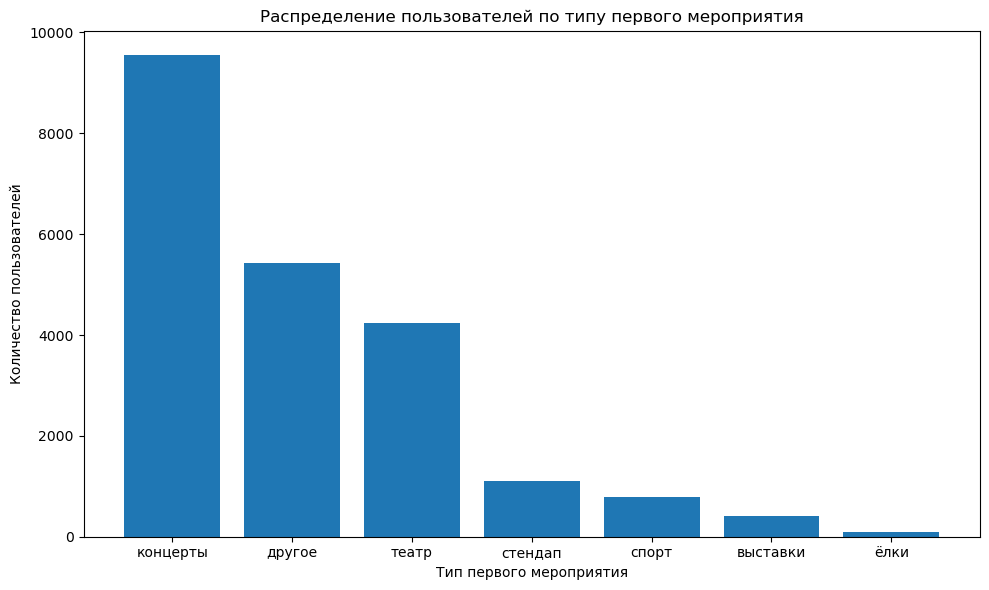

In [28]:
plt.figure(figsize=(10, 6))
plt.bar(genre_segments['Тип первого мероприятия'], genre_segments['Количество пользователей'])
plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

44% пользователей пришли с концертных мероприятий - явный лидер по притоку. С 'других' и театров в совокупности примерно такое же количество. Остальные - существенно меньше.

In [29]:
device_segments = user_profile['first_device'].value_counts().reset_index()
device_segments.columns = ['Тип первого устройства', 'Количество пользователей']
device_segments['Доля (%)'] = (device_segments['Количество пользователей'] / len(user_profile) * 100).round(2)
device_segments

,Тип первого устройства,Количество пользователей,Доля (%)
0,mobile,17924,82.84
1,desktop,3714,17.16


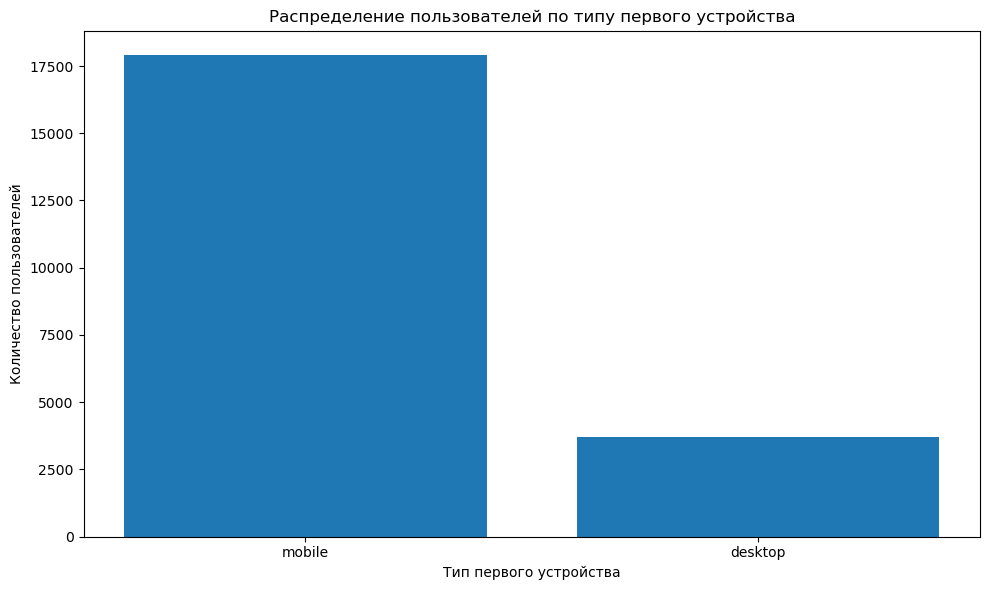

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(device_segments['Тип первого устройства'], device_segments['Количество пользователей'])
plt.title('Распределение пользователей по типу первого устройства')
plt.xlabel('Тип первого устройства')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

83% пользователей впервые воспользовались афишей с мобильного телефона. Доля десктопов невелика по притоку.

In [31]:
region_segments = user_profile['first_region'].value_counts().reset_index()
region_segments.columns = ['Первый регион', 'Количество пользователей']
region_segments['Доля (%)'] = (region_segments['Количество пользователей'] / len(user_profile) * 100).round(2)
region_segments = region_segments.sort_values('Количество пользователей', ascending=False)
region_segments.head(10)

,Первый регион,Количество пользователей,Доля (%)
0,Каменевский регион,7085,32.74
1,Североярская область,3767,17.41
2,Широковская область,1224,5.66
3,Озернинский край,675,3.12
4,Малиновоярский округ,525,2.43
5,Шанырский регион,500,2.31
6,Травяная область,488,2.26
7,Светополянский округ,457,2.11
8,Речиновская область,440,2.03
9,Яблоневская область,411,1.90


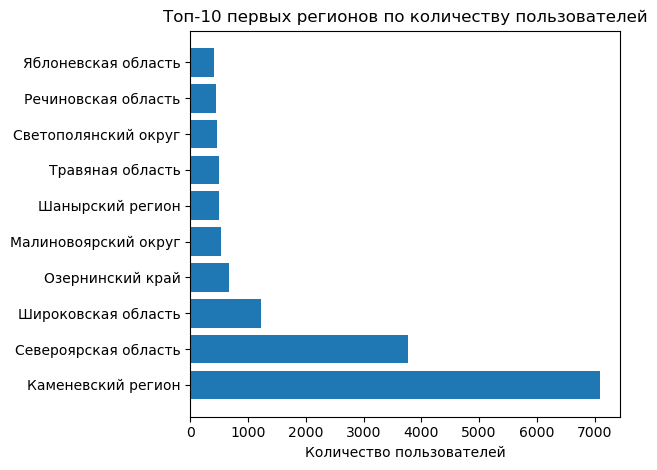

In [32]:
# Берем топ-10 регионов
top_10 = region_segments.head(10).copy()

# Горизонтальный барплот (для удобства чтения названий регионов)
plt.barh(top_10['Первый регион'], top_10['Количество пользователей'])
plt.xlabel('Количество пользователей')
plt.title('Топ-10 первых регионов по количеству пользователей')

plt.tight_layout()
plt.show()

Каменевский регион и Североярская область - лидеры среди регионов по притоку новых пользователей.

In [33]:
# Группировка по билетному оператору первого заказа (first_partner)
partner_segments = user_profile['first_partner'].value_counts().reset_index()
partner_segments.columns = ['Билетный оператор', 'Количество пользователей']
partner_segments['Доля (%)'] = (partner_segments['Количество пользователей'] / len(user_profile) * 100).round(2)
partner_segments = partner_segments.sort_values('Количество пользователей', ascending=False)
partner_segments.head(10)

,Билетный оператор,Количество пользователей,Доля (%)
0,Билеты без проблем,5186,23.97
1,Мой билет,2969,13.72
2,Лови билет!,2809,12.98
3,Билеты в руки,2559,11.83
4,Облачко,2177,10.06
5,Весь в билетах,1285,5.94
6,Лучшие билеты,1184,5.47
7,Прачечная,583,2.69
8,Край билетов,454,2.10
9,Дом культуры,356,1.65


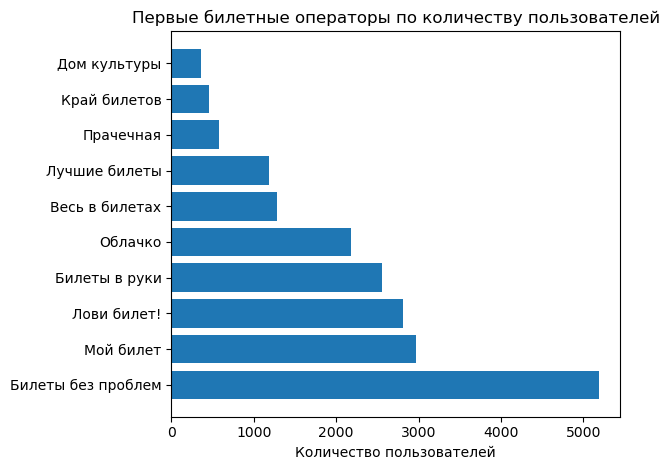

In [34]:
# Сортируем данные по убыванию количества пользователей
partner_segments_sorted = partner_segments.head(10).copy()

# Строим горизонтальную столбчатую диаграмму
plt.barh(partner_segments_sorted['Билетный оператор'], 
         partner_segments_sorted['Количество пользователей'])
plt.xlabel('Количество пользователей')
plt.title('Первые билетные операторы по количеству пользователей')

plt.tight_layout()
plt.show()

Среди билетных операторов особенно выделяется Билеты без проблем. Относительно неплохо по приросту показали себя Мой билет, Лови билет!, Билеты в руки и Облачко.

Промежуточный вывод:

Ярко выражены точки входа в каждом из сегментов

- 44% пришли с концертов
- 83% с мобильных телефонов
- 50% зарегистрированы в Каменевском регионе и Североярской области
- 24% купили первые билеты у Билеты без проблем

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Проведем примерно те же операции, но теперь с учетом вернувшихся пользователей

In [35]:
# Группировка по типу первого мероприятия (first_genre)

genre_segments_2 = user_profile.groupby('first_genre', as_index=False)[['user_id', 'is_two']].agg({
    'user_id': 'count',
    'is_two': 'sum'
    })

genre_segments_2['ratio'] = (genre_segments_2['is_two'] / genre_segments_2['user_id']).round(2)
genre_segments_2 = genre_segments_2.sort_values('user_id', ascending=False)
genre_segments_2

,first_genre,user_id,is_two,ratio
2,концерты,9560,5911,0.62
1,другое,5426,3235,0.60
5,театр,4239,2687,0.63
4,стендап,1110,676,0.61
3,спорт,794,443,0.56
0,выставки,414,265,0.64
6,ёлки,95,53,0.56


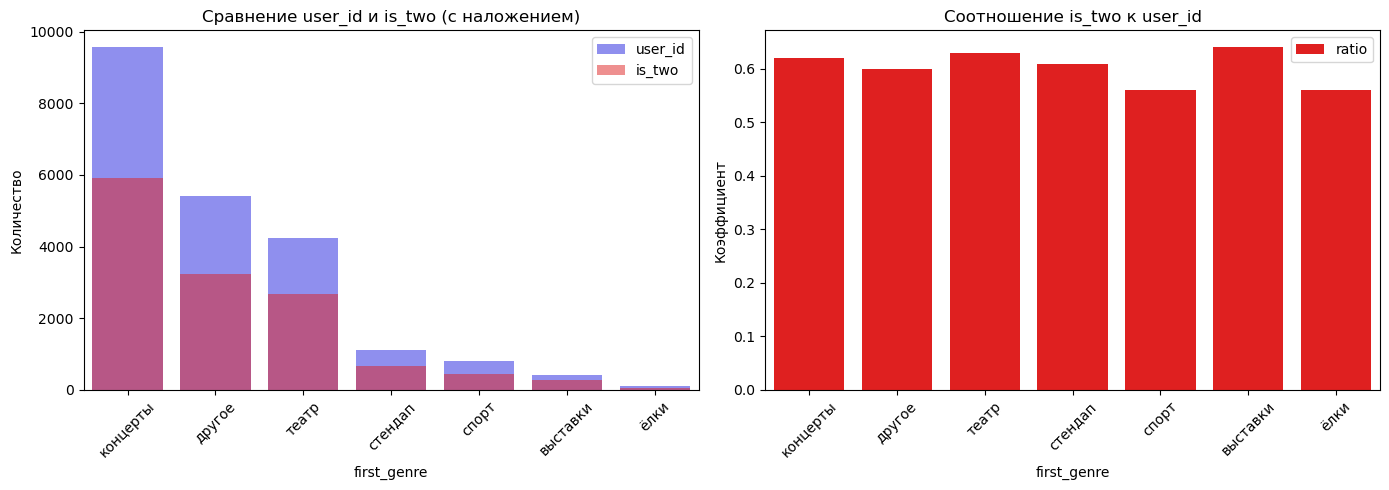

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей по жанрам
sns.barplot(data=genre_segments_2, x='first_genre', y='user_id', ax=axes[0], 
            color='blue', alpha=0.5, label='user_id')
sns.barplot(data=genre_segments_2, x='first_genre', y='is_two', ax=axes[0], 
            color='red', alpha=0.5, label='is_two')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение user_id и is_two (с наложением)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# График 2: Соотношение is_two/user_id
sns.barplot(data=genre_segments_2, x='first_genre', y='ratio', ax=axes[1], 
            color='red', label='ratio')
axes[1].set_title('Соотношение is_two к user_id')
axes[1].set_ylabel('Коэффициент')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

Доля вернувшихся польователей чуть выше у выставок. Самая низкая у елок, но, в целом, количество пользователей достаточно низкое по этим жанрам.

In [37]:
device_segments_2 = user_profile.groupby('first_device', as_index=False)[['user_id', 'is_two']].agg({
    'user_id': 'count',
    'is_two': 'sum'
    })

device_segments_2['ratio'] = (device_segments_2['is_two'] / device_segments_2['user_id']).round(2)
device_segments_2 = device_segments_2.sort_values('user_id', ascending=False)
device_segments_2

,first_device,user_id,is_two,ratio
1,mobile,17924,10900,0.61
0,desktop,3714,2370,0.64


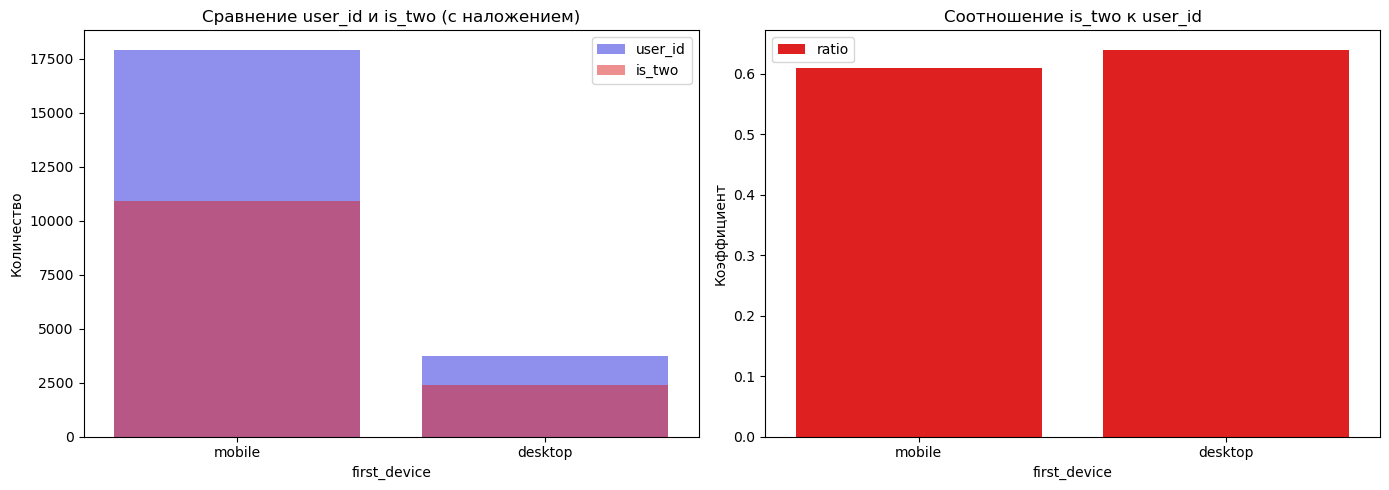

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей по девайсам
sns.barplot(data=device_segments_2, x='first_device', y='user_id', ax=axes[0], 
            color='blue', alpha=0.5, label='user_id')
sns.barplot(data=device_segments_2, x='first_device', y='is_two', ax=axes[0], 
            color='red', alpha=0.5, label='is_two')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение user_id и is_two (с наложением)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# График 2: Соотношение is_two/user_id
sns.barplot(data=device_segments_2, x='first_device', y='ratio', ax=axes[1], 
            color='red', label='ratio')
axes[1].set_title('Соотношение is_two к user_id')
axes[1].set_ylabel('Коэффициент')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

Тоже достаточно равномерное распределение по долям.

In [39]:
region_segments_2 = user_profile.groupby('first_region', as_index=False)[['user_id', 'is_two']].agg({
    'user_id': 'count',
    'is_two': 'sum'
    })

region_segments_2['ratio'] = (region_segments_2['is_two'] / region_segments_2['user_id']).round(2)
region_segments_2 = region_segments_2.sort_values('user_id', ascending=False).head(10)
region_segments_2

,first_region,user_id,is_two,ratio
23,Каменевский регион,7085,4421,0.62
60,Североярская область,3767,2404,0.64
77,Широковская область,1224,790,0.65
45,Озернинский край,675,373,0.55
41,Малиновоярский округ,525,294,0.56
76,Шанырский регион,500,336,0.67
74,Травяная область,488,300,0.61
57,Светополянский округ,457,300,0.66
52,Речиновская область,440,279,0.63
78,Яблоневская область,411,244,0.59


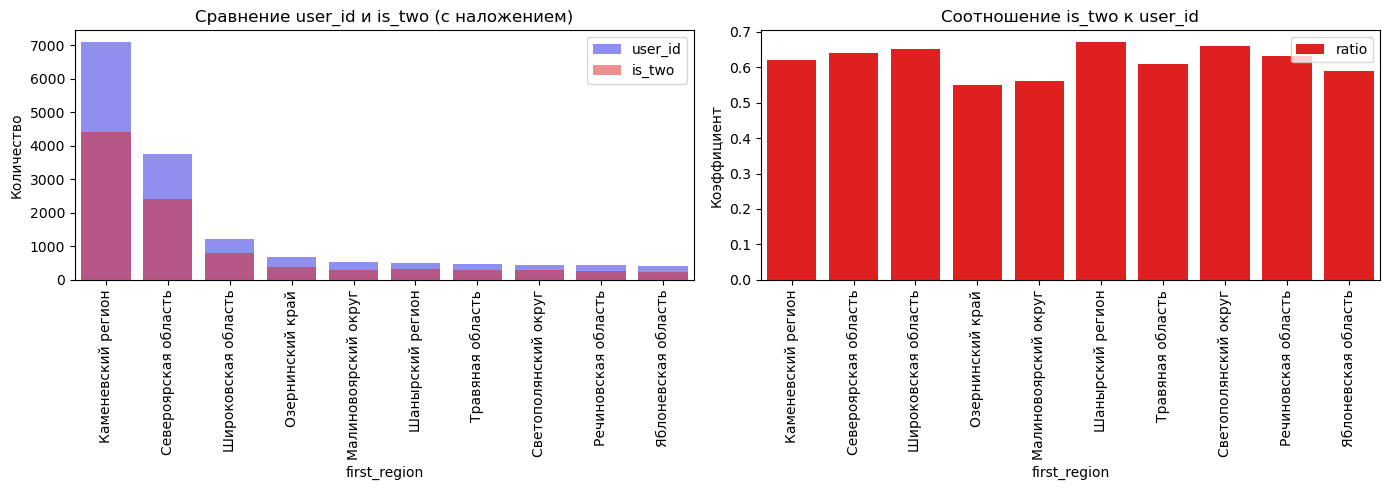

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей по регионам
sns.barplot(data=region_segments_2, x='first_region', y='user_id', ax=axes[0], 
            color='blue', alpha=0.5, label='user_id')
sns.barplot(data=region_segments_2, x='first_region', y='is_two', ax=axes[0], 
            color='red', alpha=0.5, label='is_two')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение user_id и is_two (с наложением)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)

# График 2: Соотношение is_two/user_id
sns.barplot(data=region_segments_2, x='first_region', y='ratio', ax=axes[1], 
            color='red', label='ratio')
axes[1].set_title('Соотношение is_two к user_id')
axes[1].set_ylabel('Коэффициент')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

Графики оставил горизонтальными для легкости восприятия при сравнении с остальными. 

Дифференциация по долям вернувшихся пользователей есть среди регионов. Малиновский округ и Озернинский край имеют наименьшую долю, а Шанырский регион и Широковская область - наибольшую. Но данных по этим группам маловато.


In [41]:
partner_segments_2 = user_profile.groupby('first_partner', as_index=False)[['user_id', 'is_two']].agg({
    'user_id': 'count',
    'is_two': 'sum'
    })

partner_segments_2['ratio'] = (partner_segments_2['is_two'] / partner_segments_2['user_id']).round(2)
partner_segments_2 = partner_segments_2.sort_values('user_id', ascending=False).head(10)
partner_segments_2

,first_partner,user_id,is_two,ratio
3,Билеты без проблем,5186,3133,0.60
22,Мой билет,2969,1807,0.61
19,Лови билет!,2809,1711,0.61
4,Билеты в руки,2559,1605,0.63
23,Облачко,2177,1334,0.61
7,Весь в билетах,1285,808,0.63
20,Лучшие билеты,1184,725,0.61
24,Прачечная,583,365,0.63
17,Край билетов,454,296,0.65
12,Дом культуры,356,230,0.65


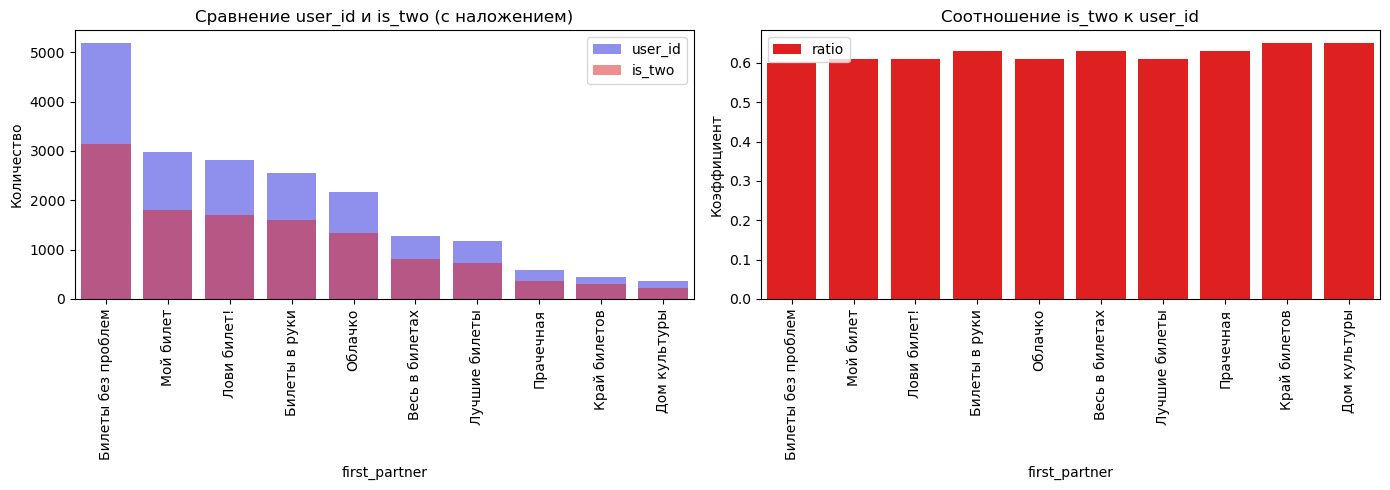

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей по партнерам
sns.barplot(data=partner_segments_2, x='first_partner', y='user_id', ax=axes[0], 
            color='blue', alpha=0.5, label='user_id')
sns.barplot(data=partner_segments_2, x='first_partner', y='is_two', ax=axes[0], 
            color='red', alpha=0.5, label='is_two')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение user_id и is_two (с наложением)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)

# График 2: Соотношение is_two/user_id
sns.barplot(data=partner_segments_2, x='first_partner', y='ratio', ax=axes[1], 
            color='red', label='ratio')
axes[1].set_title('Соотношение is_two к user_id')
axes[1].set_ylabel('Коэффициент')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

Графики оставил горизонтальными для легкости восприятия при сравнении с остальными.

Тоже очень равномерное распределение.

Промежуточный вывод:

В целом, есть некоторая дифференциация по долям вернувшихся пользователей среди сегментов, но без ярковыраженных аутсайдеров или лидеров по удержанию пользователей.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1

Доля пользователей, совершивших первый заказ на спортив. мероприятиях, одна из самых низких - 0.56. У концертов - 0.62.

Гипотеза 2

Каменевский регион и Свевероярская область имеют доли 0.62 и 0.64 соответственно. Однако, есть менее популярные регионы с долями выше - Шанырский регион, Светополянский округ.

---

#### Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


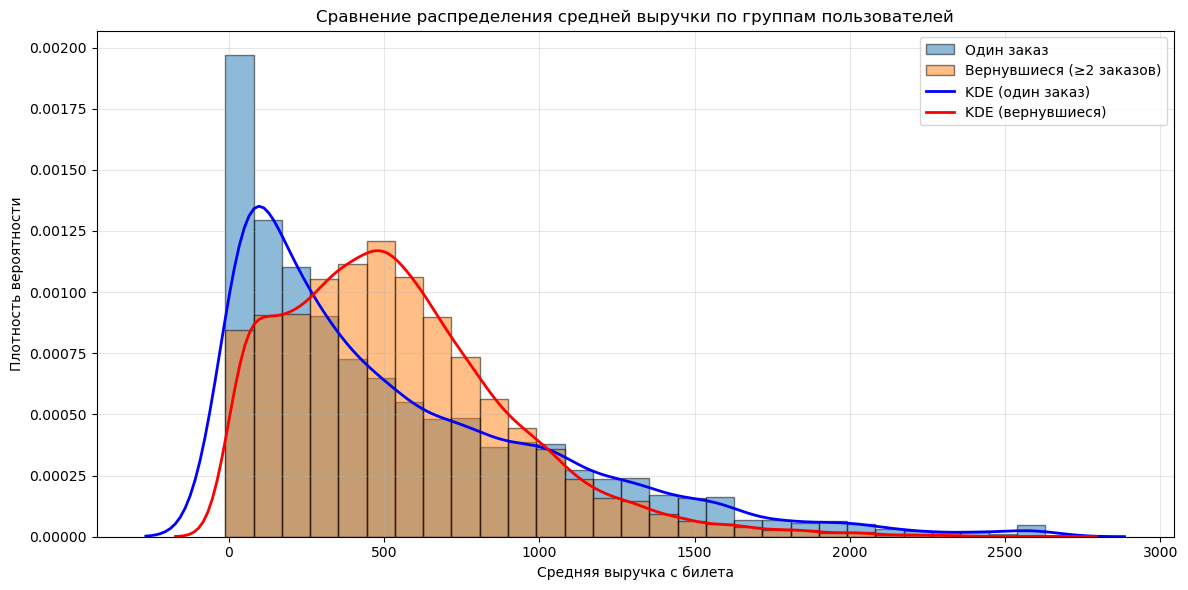

Группа 1 заказ: 8368 пользователей
Группа от 2 заказов: 13270 пользователей


In [43]:
order_1 = user_profile[user_profile['is_two'] == 0]['avg_revenue'].copy()
order_2 = user_profile[user_profile['is_two'] == 1]['avg_revenue'].copy()

# Определяем общие границы для бинов, чтобы гистограммы были сопоставимы
min_val = min(order_1.min(), order_2.min())
max_val = max(order_1.max(), order_2.max())
bins = np.linspace(min_val, max_val, 30)

plt.figure(figsize=(12, 6))
plt.hist(order_1, bins=bins, alpha=0.5, label='Один заказ', edgecolor='black', density=True)
plt.hist(order_2, bins=bins, alpha=0.5, label='Вернувшиеся (≥2 заказов)', edgecolor='black', density=True)
sns.kdeplot(data=order_1, color='blue', linewidth=2, label='KDE (один заказ)', fill=False)
sns.kdeplot(data=order_2, color='red', linewidth=2, label='KDE (вернувшиеся)', fill=False)
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределения средней выручки по группам пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Добавим информацию о размерах групп
print(f"Группа 1 заказ: {len(order_1)} пользователей")
print(f"Группа от 2 заказов: {len(order_2)} пользователей")

Наблюдается хорошее различие между группами. Пользователи с одним заказом наиболее сконцентрированы вокруг диапазона 0-300 рублей, в то время как вернувшиеся - в диапазоне 300-600.
Это говорит о том, что пользователи, потратившие больше денег на билеты, имеют тенденцию чаще возвращаться за покупками.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


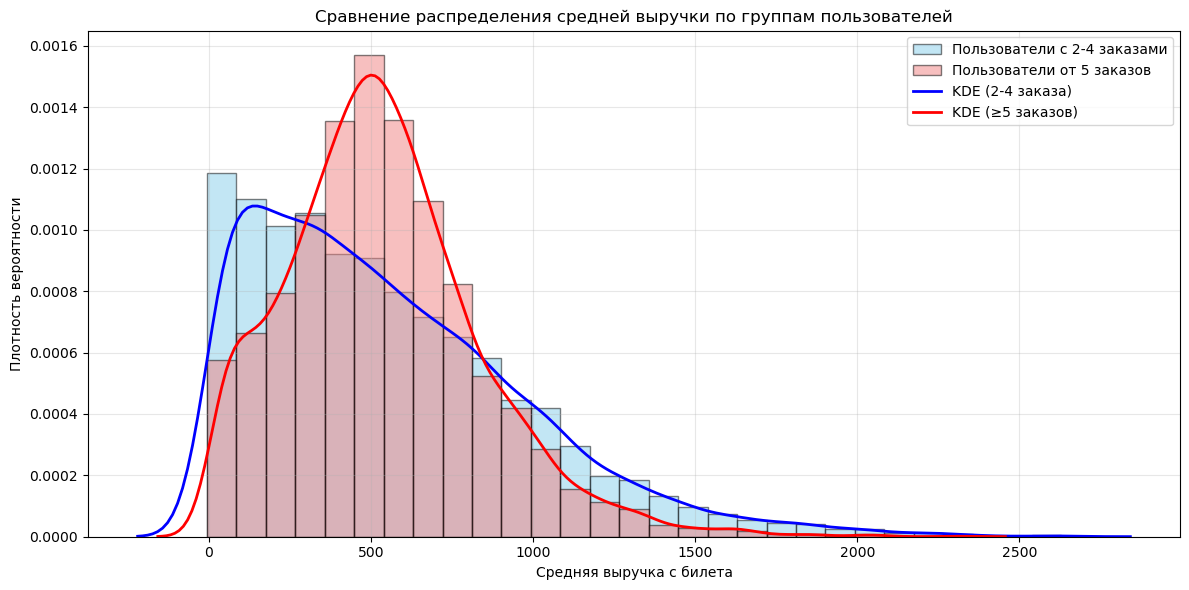

Группа 2-4 заказа: 7147 пользователей
Группа ≥5 заказов: 6123 пользователей


In [44]:
order_2_4 = user_profile[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0)]['avg_revenue'].copy()
order_5 = user_profile[user_profile['is_five'] == 1]['avg_revenue'].copy()

# Определяем общие границы для бинов, чтобы гистограммы были сопоставимы
min_val = min(order_2_4.min(), order_5.min())
max_val = max(order_2_4.max(), order_5.max())
bins = np.linspace(min_val, max_val, 30)

plt.figure(figsize=(12, 6))
plt.hist(order_2_4, bins=bins, alpha=0.5, label='Пользователи с 2-4 заказами', 
         edgecolor='black', density=True, color='skyblue')
plt.hist(order_5, bins=bins, alpha=0.5, label='Пользователи от 5 заказов', 
         edgecolor='black', density=True, color='lightcoral')
sns.kdeplot(data=order_2_4, color='blue', linewidth=2, label='KDE (2-4 заказа)', fill=False)
sns.kdeplot(data=order_5, color='red', linewidth=2, label='KDE (≥5 заказов)', fill=False)
plt.xlabel('Средняя выручка с билета')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределения средней выручки по группам пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Добавим информацию о размерах групп
print(f"Группа 2-4 заказа: {len(order_2_4)} пользователей")
print(f"Группа ≥5 заказов: {len(order_5)} пользователей")

Основная масса вернувшихся пользовтателей, совершившая покупки билетов в диапазоне 300-600 рублей, возвращалась чаще всего - они совершили покупки более 5 раз.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Статистика по сегментам пользователей:


,Сегмент,Всего пользователей,Повторные заказы,Доля повторных (%)
0,1-2 билета,2419,1241,51.30
1,2-3 билета,9498,6989,73.58
2,3-5 билетов,9060,4916,54.26
3,5+ билетов,661,124,18.76


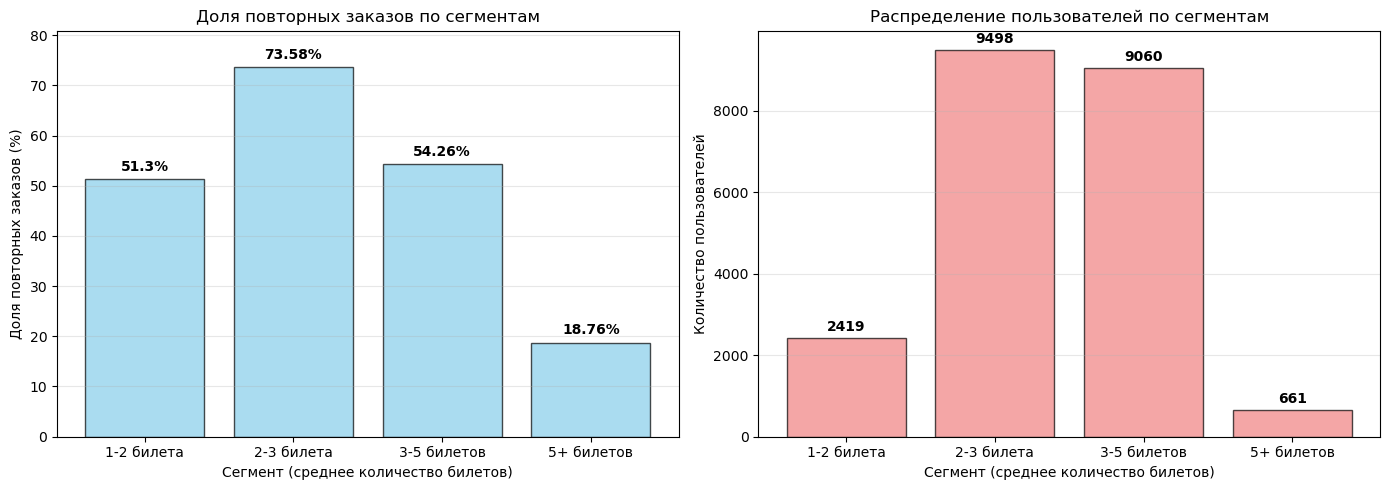

Сводная информация:
Всего пользователей во всех сегментах: 21638
Всего пользователей с повторными заказами: 13270
Общая доля повторных заказов: 61.33%


In [45]:
# Создаем сегменты по среднему количеству билетов в заказе
segment_1_2 = user_profile[(user_profile['avg_tickets'] >= 1) & (user_profile['avg_tickets'] < 2)]['is_two'].copy()
segment_2_3 = user_profile[(user_profile['avg_tickets'] >= 2) & (user_profile['avg_tickets'] < 3)]['is_two'].copy()
segment_3_5 = user_profile[(user_profile['avg_tickets'] >= 3) & (user_profile['avg_tickets'] < 5)]['is_two'].copy()
segment_5_plus = user_profile[user_profile['avg_tickets'] >= 5]['is_two'].copy()

# Функция для расчета статистики по сегменту
def calculate_segment_stats(segment, segment_name):
    total_users = len(segment)
    repeat_users = segment.sum()  # is_two = 1 для повторных заказов
    repeat_share = (repeat_users / total_users * 100) if total_users > 0 else 0
    
    return {
        'Сегмент': segment_name,
        'Всего пользователей': total_users,
        'Повторные заказы': repeat_users,
        'Доля повторных (%)': round(repeat_share, 2)
    }

# Собираем статистику по всем сегментам
results = []
results.append(calculate_segment_stats(segment_1_2, '1-2 билета'))
results.append(calculate_segment_stats(segment_2_3, '2-3 билета'))
results.append(calculate_segment_stats(segment_3_5, '3-5 билетов'))
results.append(calculate_segment_stats(segment_5_plus, '5+ билетов'))

# Создаем DataFrame с результатами
segment_stats = pd.DataFrame(results)

# Выводим результаты
print("Статистика по сегментам пользователей:")
display(segment_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График доли повторных заказов
bars1 = axes[0].bar(segment_stats['Сегмент'], segment_stats['Доля повторных (%)'], 
                    color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Сегмент (среднее количество билетов)')
axes[0].set_ylabel('Доля повторных заказов (%)')
axes[0].set_title('Доля повторных заказов по сегментам')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(segment_stats['Доля повторных (%)']) * 1.1)

# Добавляем значения на столбцы
for bar, value in zip(bars1, segment_stats['Доля повторных (%)']):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{value}%', ha='center', va='bottom', fontweight='bold')

# График количества пользователей
bars2 = axes[1].bar(segment_stats['Сегмент'], segment_stats['Всего пользователей'], 
                    color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Сегмент (среднее количество билетов)')
axes[1].set_ylabel('Количество пользователей')
axes[1].set_title('Распределение пользователей по сегментам')
axes[1].grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, value in zip(bars2, segment_stats['Всего пользователей']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(segment_stats['Всего пользователей'])*0.01,
                 f'{value}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Дополнительная информация
print("Сводная информация:")
total_users_all = segment_stats['Всего пользователей'].sum()
total_repeat_all = segment_stats['Повторные заказы'].sum()
print(f"Всего пользователей во всех сегментах: {total_users_all}")
print(f"Всего пользователей с повторными заказами: {total_repeat_all}")
print(f"Общая доля повторных заказов: {(total_repeat_all/total_users_all*100):.2f}%")

Больше половины пользователей совершили повторные заказы.

Наибольшее количество пользователей сосредоточено в двух сегментах: 2-3 и 3-5 билетов.

Чаще всего пользователи возвращаются за покупкой 2-3 билетов и реже всего больше 4-х.

---

#### Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [46]:
user_profile['day_of_week'] = user_profile['first_order_date'].dt.day_name()
user_profile.head()

,user_id,first_order_date,last_order_date,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue,avg_tickets,avg_days_since_prev,is_two,is_five,day_of_week
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0,Tuesday
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,1,0,Tuesday
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,1,0,Saturday
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0,Thursday
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0,Sunday


In [47]:
user_profile_d = user_profile.groupby('day_of_week').agg(
    total_users=('user_id', 'count'),
    repeat_users=('is_two', 'sum')
).reset_index()

user_profile_d['ratio'] = (user_profile_d['repeat_users'] / user_profile_d['total_users']).round(2)

# Убедимся, что дни недели идут в правильном порядке
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
user_profile_d['day_of_week'] = pd.Categorical(user_profile_d['day_of_week'], 
                                               categories=days_order, 
                                               ordered=True)
user_profile_d = user_profile_d.sort_values('day_of_week')
user_profile_d

,day_of_week,total_users,repeat_users,ratio
1,Monday,2930,1847,0.63
5,Tuesday,3176,1966,0.62
6,Wednesday,3057,1901,0.62
4,Thursday,3113,1850,0.59
0,Friday,3259,1950,0.60
2,Saturday,3326,2089,0.63
3,Sunday,2777,1667,0.60


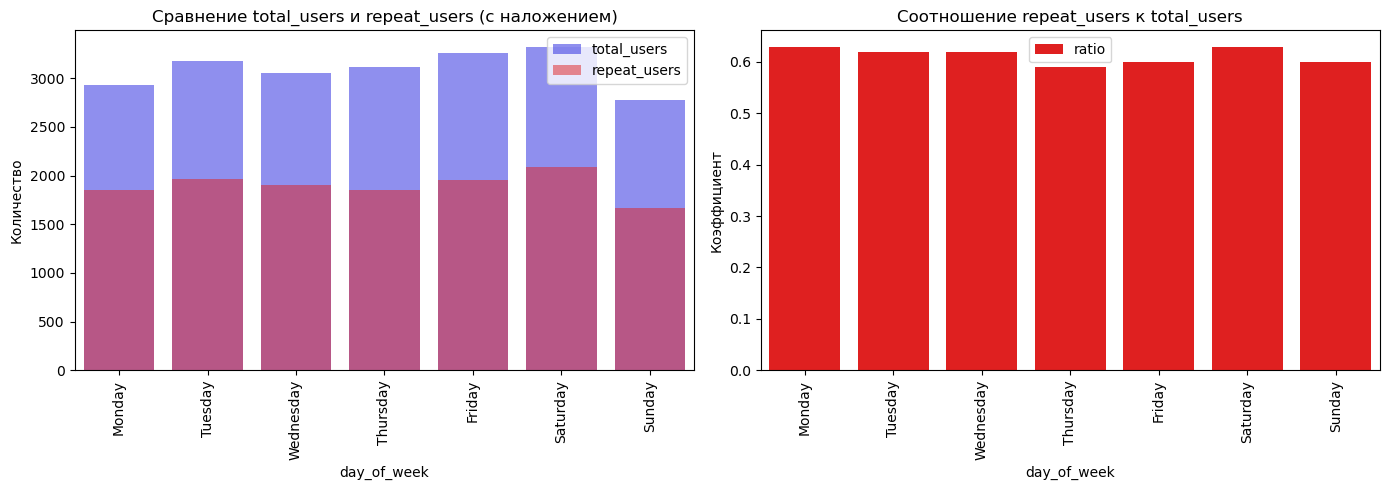

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1:
sns.barplot(data=user_profile_d, x='day_of_week', y='total_users', ax=axes[0], 
            color='blue', alpha=0.5, label='total_users')
sns.barplot(data=user_profile_d, x='day_of_week', y='repeat_users', ax=axes[0], 
            color='red', alpha=0.5, label='repeat_users')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение total_users и repeat_users (с наложением)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)

# График 2:
sns.barplot(data=user_profile_d, x='day_of_week', y='ratio', ax=axes[1], 
            color='red', label='ratio')
axes[1].set_title('Соотношение repeat_users к total_users')
axes[1].set_ylabel('Коэффициент')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

После обвала в воскресенье количество заказов постепенно растет вплоть до максимума в субботу.

Соотношение вернувшихся пользователей примерно одинаковое, можно сделать вывод о том, что день недели первого заказа слабо влияет на возврат.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


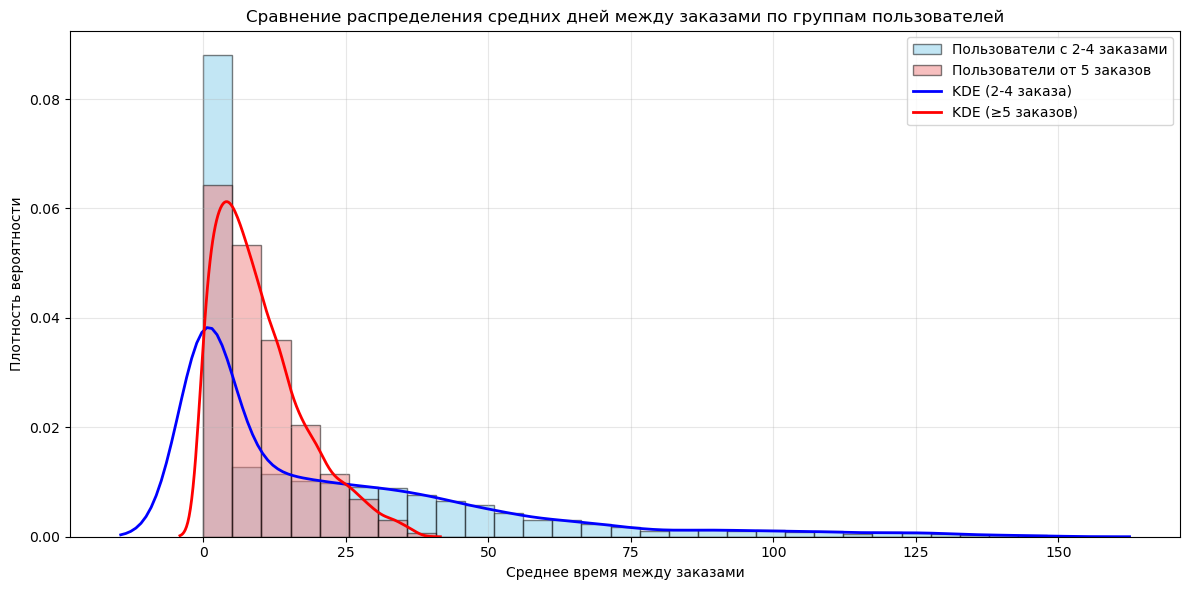

Группа 2-4 заказа: 7147 пользователей, среднее время заказа (дней): 21.3, медиана: 9.0
Группа ≥5 заказов: 6123 пользователей, среднее время заказа (дней): 9.9, медиана: 8.1


In [49]:
order_2_4 = user_profile[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0)]['avg_days_since_prev'].copy()
order_5 = user_profile[user_profile['is_five'] == 1]['avg_days_since_prev'].copy()

# Определяем общие границы для бинов, чтобы гистограммы были сопоставимы
min_val = min(order_2_4.min(), order_5.min())
max_val = max(order_2_4.max(), order_5.max())
bins = np.linspace(min_val, max_val, 30)

plt.figure(figsize=(12, 6))
plt.hist(order_2_4, bins=bins, alpha=0.5, label='Пользователи с 2-4 заказами', 
         edgecolor='black', density=True, color='skyblue')
plt.hist(order_5, bins=bins, alpha=0.5, label='Пользователи от 5 заказов', 
         edgecolor='black', density=True, color='lightcoral')
sns.kdeplot(data=order_2_4, color='blue', linewidth=2, label='KDE (2-4 заказа)', fill=False)
sns.kdeplot(data=order_5, color='red', linewidth=2, label='KDE (≥5 заказов)', fill=False)
plt.xlabel('Среднее время между заказами')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение распределения средних дней между заказами по группам пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Добавим информацию о размерах групп
print(f"Группа 2-4 заказа: {len(order_2_4)} пользователей, среднее время заказа (дней): {order_2_4.mean():.1f}, медиана: {order_2_4.median():.1f}")
print(f"Группа ≥5 заказов: {len(order_5)} пользователей, среднее время заказа (дней): {order_5.mean():.1f}, медиана: {order_5.median():.1f}")

В целом, между большинством повторных заказов проходит мало времени. Однако, пользователи, совершающие большее количество заказов, делают промежутки между заказами значительно меньше, когда у заказов в количестве 2-4 штук они могут быть сильно размазаны по времени, что логично.

---

#### Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [50]:
corr_cols = ['total_orders', 'first_order_date', 'last_order_date', 'first_device', 'first_region', 'first_partner', 'first_genre', 'avg_revenue', 'avg_tickets', 'avg_days_since_prev', 'day_of_week']
interval_cols = ['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_since_prev']

# Передаем список интервальных столбцов в функцию
corr_matrix = user_profile[corr_cols].phik_matrix(interval_cols=interval_cols)
corr_orders = (
    corr_matrix['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
   #.rename(columns={'index': 'Признак', 'total_orders': 'Корреляция'})
    .set_index('index')
)
corr_orders

,total_orders
index,
first_order_date,0.43
last_order_date,0.41
avg_days_since_prev,0.28
avg_tickets,0.23
avg_revenue,0.22
first_region,0.11
day_of_week,0.06
first_genre,0.03
first_partner,0.03


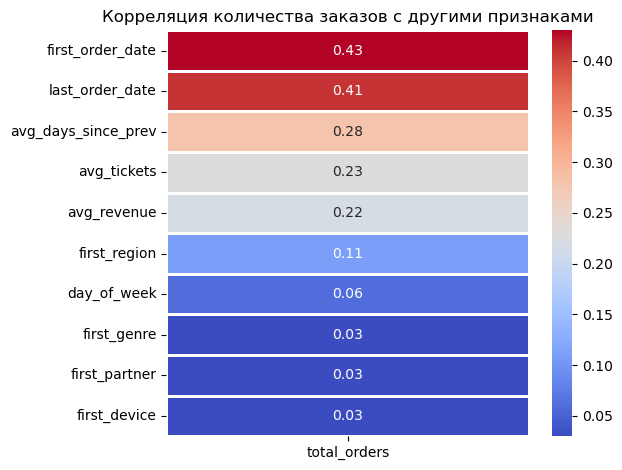

In [51]:
# Визуализация
sns.heatmap(corr_orders, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=1)
plt.title('Корреляция количества заказов с другими признаками')
plt.ylabel('')
plt.tight_layout()
plt.show()

Корреляция с датами выглядит достаточно логично, ведь, чем дольше пользователь на платформе, тем больше вероятность, что у него количество заказов окажется по итогу выше, чем у новеньких.

Картину для общего понимания получили, посмотрим на корреляцию отдельных сегментов.

In [52]:
seg_1 = user_profile[user_profile['is_two'] == 0].copy()
seg_2 = user_profile[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0)].copy()
seg_3 = user_profile[user_profile['is_five'] == 1].copy()

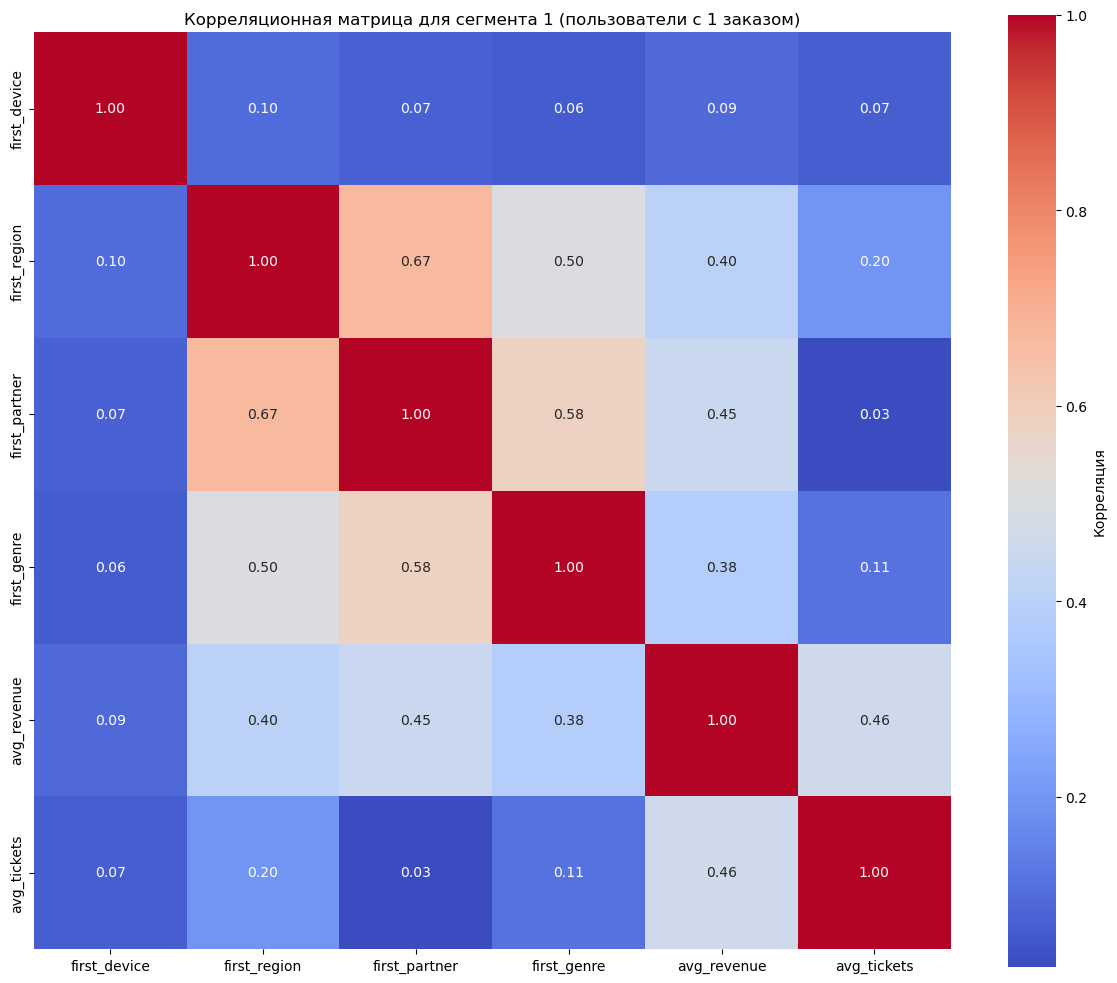

In [53]:
seg_1_cols = ['first_device', 'first_region', 'first_partner', 'first_genre', 'avg_revenue', 'avg_tickets']
seg_1_int = ['avg_revenue', 'avg_tickets']

seg_1 = seg_1[seg_1_cols].copy()

seg_1_phik = seg_1.phik_matrix(interval_cols=seg_1_int)

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(seg_1_phik, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={'label': 'Корреляция'})
plt.title('Корреляционная матрица для сегмента 1 (пользователи с 1 заказом)')
plt.tight_layout()
plt.show()

В связи с тем, что заказ всего 1 в отфильтрованных данных, сравниваем не поле `total_orders`, а оставшиеся поля между собой. Но для наших целей этот анализ не подходит, так как противоречит заданию. Представлен, чтобы был.

Здесь можно увидеть, что наивысшими коэффициетами обладает пара первый партнер / первый регион - продавцы билетов в большинстве несетевые и представлены в определенных городах.

Первый жанр / первый партнер - продавцы билетов чаще специализируются на чем-то одном.

Среднее количество билетов / средняя выручка тоже понятно - чем больше билетов, тем больше выручка.

Первый партнер / средняя выручка - стоимость билетов у каждого партнера не особо дифференцирована.

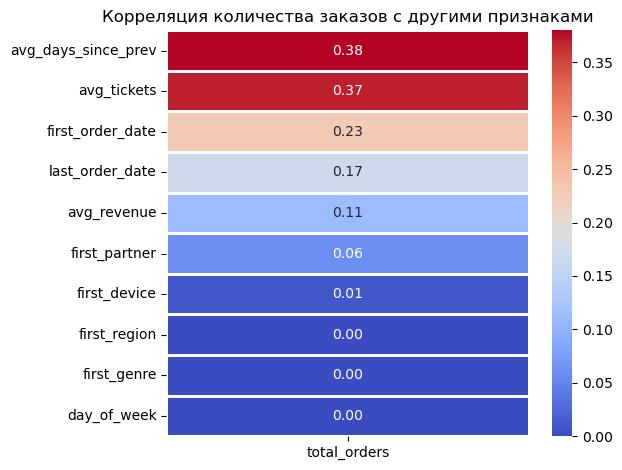

In [54]:
seg_2_matrix = seg_2[corr_cols].phik_matrix(interval_cols=interval_cols)
corr_seg_2 = (
    seg_2_matrix['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
    .set_index('index')
)
# Визуализация
sns.heatmap(corr_seg_2, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=1)
plt.title('Корреляция количества заказов с другими признаками')
plt.ylabel('')
plt.tight_layout()
plt.show()

Корреляция для сегмента 2-4 между количеством заказов и средним количеством дней между покупками, а также средним количеством билетов стала сильнее.

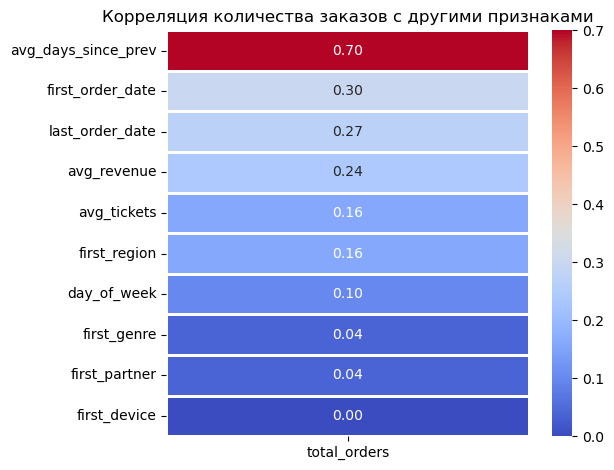

In [55]:
seg_3_matrix = seg_3[corr_cols].phik_matrix(interval_cols=interval_cols)
corr_seg_3 = (
    seg_3_matrix['total_orders']
    .drop('total_orders')
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
    .set_index('index')
)
# Визуализация
sns.heatmap(corr_seg_3, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=1)
plt.title('Корреляция количества заказов с другими признаками')
plt.ylabel('')
plt.tight_layout()
plt.show()

Сильная, устойчивая корреляция для сегмента 5+ между количеством заказов и средним количеством дней между покупками.

Возможно, билеты приобретают организации для сотрудников?

### Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

---
***Информация о данных***
- Написали SQL-запрос, загрузили его в DataFrame
- Таблица содержит 15 столбцов и 290611 строк
- Подгрузили таблицу с курсом тенге, добавили новый столбец с данными только в рублях
- Посмотрели пропуски, явных дубликатов не обнаружили
- Проверили уникальные значения в категориальных столбцах - ничего криминального не обнаружили
- Построили ящики по столбцам `revenue_rub` и `tickets_count`, нашли в первом случае сильные выбросы
- Отфильтровали `df` по 99 процентилю `revenue_rub` (~1%), осталось 287786 строк

***Основные результаты***
- Общее число пользователей в выборке: 21854. Доля пользователей с 2+ заказами: 61.71%. Доля пользователей с 5+ заказами: 29.01%.
- Приняли решение избавиться от выбросов 99 перцентиля по полю total_orders, так как это не настолько сильно сказалось на итоговой статистике, но позволило избавиться от экстремальных выбросов. Осталось 21638 строк.
- Ярко выражены точки входа в каждом из сегментов:
 - 44% пришли с концертов
 - 83% с мобильных телефонов
 - 50% зарегистрированы в Каменевском регионе и Североярской области
 - 24% купили первые билеты у Билеты без проблем
- Пользователи, потратившие больше денег на билеты, имеют тенденцию чаще возвращаться за покупками:
 - Больше половины пользователей совершили повторные заказы.
 - Наибольшее количество пользователей сосредоточено в двух сегментах: 2-3 и 3-5 билетов.
 - Чаще всего пользователи возвращаются за покупкой 2-3 билетов и реже всего больше 4-х.
- В целом, есть некоторая дифференциация по долям вернувшихся пользователей среди сегментов, но без ярковыраженных аутсайдеров или лидеров по удержанию пользователей.
- В целом, между большинством повторных заказов проходит мало времени. Однако, пользователи, совершающие большее количество заказов, делают промежутки между заказами значительно меньше, когда у заказов в количестве 2-4 штук они могут быть сильно размазаны по времени, что логично.
- Самая сильная, устойчивая корреляция - между количеством заказов и средним количеством дней между покупками (для сегмента от пяти заказов).

***Рекомендации***

**1. Основной фокус: удержание "Золотого ядра" (5+ заказов)**
*   **Кто это:** 29% аудитории с самым высоким чеком и минимальными промежутками между покупками.
*   **Что делать:** Внедрить программу лояльности (кешбэк, ранний доступ к концертам) и механики рефералов («приведи друга»), чтобы стимулировать их приводить новых клиентов.

**2. Приоритет развития: активация сегмента «Регулярные» (3–5 заказов)**
*   **Кто это:** Крупный сегмент, который уже доказал лояльность, но еще не дошел до максимальных показателей.
*   **Что делать:** Стимулировать их к увеличению частоты покупок с помощью **кросс-продаж** (рекомендация билетов на смежные события сразу после покупки).

**3. Зона роста: работа с «Новичками» (2–3 заказа)**
*   **Кто это:** Самый массовый сегмент (ядро базы), совершающий повторные, но редкие покупки.
*   **Что делать:**
    *   Запустить автоматические **триггерные коммуникации** (напоминания), чтобы сократить «размазанные» по времени промежутки между заказами.
    *   Использовать данные о первых покупках (24% у «Билеты без проблем») для персонализации предложений.

**Ключевой канал и гео:**
*   Сделать упор на **мобильную версию** (83% трафика) и усиливать активность в **Каменевском регионе и Североярской области** (50% базы).

### Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

In [56]:
**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

SyntaxError: invalid syntax (1939400329.py, line 1)